<a href="https://colab.research.google.com/github/yaspitanga/Sistematizacao_CD2_HR_Analytics/blob/main/Sistematizacao_CD2_Pipeline_KDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving HR_Analytics.csv to HR_Analytics.csv


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

# Initialize SparkSession
spark = SparkSession.builder.appName("HR_Analytics").getOrCreate()

# Load the dataset
df_spark = spark.read.csv('HR_Analytics.csv', header=True, inferSchema=True)

# 1. Removendo colunas que têm o mesmo valor para todo mundo (não ajudam na análise)
colunas_para_tirar = ['EmployeeCount', 'StandardHours', 'Over18']
df_limpo = df_spark.drop(*colunas_para_tirar)

# 2. Criando uma coluna nova onde 'Yes' vira 1 e 'No' vira 0 (para podermos fazer cálculos)
df_limpo = df_limpo.withColumn(
    "Attrition_Num",
    when(col("Attrition") == "Yes", 1).otherwise(0)
)

print("Dados limpos com sucesso!")
print("Número de colunas originais:", len(df_spark.columns))
print("Número de colunas atuais:", len(df_limpo.columns))

Dados limpos com sucesso!
Número de colunas originais: 38
Número de colunas atuais: 36


=== PERGUNTAS DE NEGÓCIO ===

1. Média de Idade e Salário por Nível do Cargo:
+-----------+-----------+-------------+
|Nivel_Cargo|Media_Idade|Media_Salario|
+-----------+-----------+-------------+
|          1|       32.5|      2789.08|
|          2|       36.6|      5504.01|
|          3|       40.1|      9822.75|
|          4|       47.5|     15471.33|
|          5|       47.8|     19191.83|
+-----------+-----------+-------------+

2. Média de Tempo de Empresa por Status de Saída:
+---------------+------------------+------------------+
|Saiu_Da_Empresa|Media_Anos_Empresa|Total_Funcionarios|
+---------------+------------------+------------------+
|             No|               7.4|              1242|
|            Yes|               5.1|               238|
+---------------+------------------+------------------+

3. Média Salarial por Nível de Escolaridade:
+----------------+--------------------+-------------+
|Cod_Escolaridade|        Escolaridade|Media_Salario|
+----------------+---

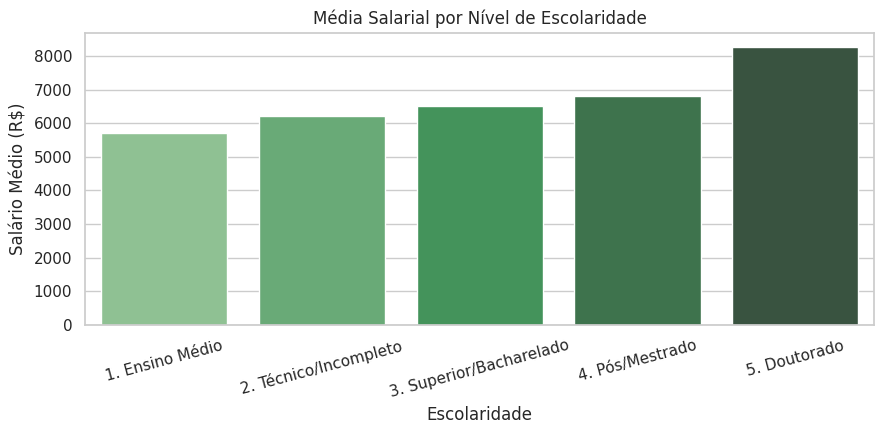

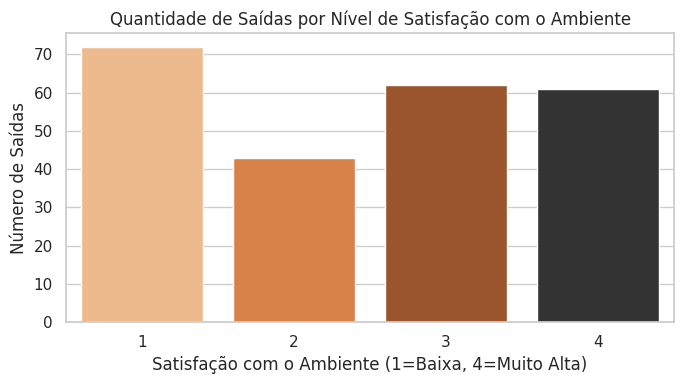

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Registrando a tabela no Spark
df_limpo.createOrReplaceTempView("tabela_rh")

sns.set_theme(style="whitegrid")

print("=== PERGUNTAS DE NEGÓCIO ===\n")

# Pergunta 1: Qual a média de idade e salário para cada nível de cargo?
print("1. Média de Idade e Salário por Nível do Cargo:")
q1 = spark.sql("""
    SELECT
        JobLevel as Nivel_Cargo,
        ROUND(AVG(Age), 1) as Media_Idade,
        ROUND(AVG(MonthlyIncome), 2) as Media_Salario
    FROM tabela_rh
    GROUP BY JobLevel
    ORDER BY Nivel_Cargo
""")
q1.show()

# Pergunta 2: Qual a média de tempo de empresa de quem saiu vs quem ficou?
print("2. Média de Tempo de Empresa por Status de Saída:")
q2 = spark.sql("""
    SELECT
        Attrition as Saiu_Da_Empresa,
        ROUND(AVG(YearsAtCompany), 1) as Media_Anos_Empresa,
        COUNT(*) as Total_Funcionarios
    FROM tabela_rh
    GROUP BY Attrition
""")
q2.show()

# Pergunta 3: Qual a média salarial por nível de escolaridade (com legenda clara)?
print("3. Média Salarial por Nível de Escolaridade:")
q3 = spark.sql("""
    SELECT
        Education as Cod_Escolaridade,
        CASE Education
            WHEN 1 THEN '1. Ensino Médio'
            WHEN 2 THEN '2. Técnico/Incompleto'
            WHEN 3 THEN '3. Superior/Bacharelado'
            WHEN 4 THEN '4. Pós/Mestrado'
            WHEN 5 THEN '5. Doutorado'
            ELSE 'Não Informado'
        END as Escolaridade,
        ROUND(AVG(MonthlyIncome), 2) as Media_Salario
    FROM tabela_rh
    GROUP BY Education
    ORDER BY Education
""")
q3.show()

# Pergunta 4: Quantos funcionários de cada estado civil fazem hora extra?
print("4. Hora Extra realizada por Estado Civil:")
q4 = spark.sql("""
    SELECT
        MaritalStatus as Estado_Civil,
        OverTime as Faz_Hora_Extra,
        COUNT(*) as Total
    FROM tabela_rh
    GROUP BY MaritalStatus, OverTime
    ORDER BY Estado_Civil, OverTime
""")
q4.show()

# Pergunta 5: Quantas saídas ocorreram por nível de satisfação com o ambiente (1 a 4)?
print("5. Total de Saídas por Nível de Satisfação com o Ambiente:")
q5 = spark.sql("""
    SELECT
        EnvironmentSatisfaction as Satisfacao_Ambiente,
        COUNT(*) as Total_Saidas
    FROM tabela_rh
    WHERE Attrition = 'Yes'
    GROUP BY EnvironmentSatisfaction
    ORDER BY Satisfacao_Ambiente
""")
q5.show()

# Graficos da analise exploratoria

# Gráfico 1: Média Salarial por Escolaridade
df_q3_pd = q3.toPandas()
plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=df_q3_pd,
    x="Escolaridade",
    y="Media_Salario",
    hue="Escolaridade",
    palette="Greens_d",
    legend=False
)
plt.title("Média Salarial por Nível de Escolaridade")
plt.xlabel("Escolaridade")
plt.ylabel("Salário Médio (R$)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Gráfico 2: Saídas por Satisfação com o Ambiente
df_q5_pd = q5.toPandas()
plt.figure(figsize=(7, 4))
sns.barplot(
    data=df_q5_pd,
    x="Satisfacao_Ambiente",
    y="Total_Saidas",
    hue="Satisfacao_Ambiente",
    palette="Oranges_d",
    legend=False
)
plt.title("Quantidade de Saídas por Nível de Satisfação com o Ambiente")
plt.xlabel("Satisfação com o Ambiente (1=Baixa, 4=Muito Alta)")
plt.ylabel("Número de Saídas")
plt.tight_layout()
plt.show()

In [6]:
import warnings
warnings.filterwarnings('ignore')

from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import col

print("CONSTRUÇÃO DO MODELO PREDITIVO (MACHINE LEARNING)\n")

# 1. Definindo as colunas categóricas e numéricas
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
numeric_cols = ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike',
                'PerformanceRating', 'RelationshipSatisfaction', 'TotalWorkingYears', 'TrainingTimesLastYear',
                'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

# Limpando registros com valores nulos nas colunas do modelo
df_ml = df_limpo.na.drop(subset=categorical_cols + numeric_cols + ['Attrition'])

# Convertendo colunas numéricas para o tipo Double
for c in numeric_cols:
    df_ml = df_ml.withColumn(c, col(c).cast(DoubleType()))

# 2. Mapeamento da variável alvo (Attrition)
label_indexer = StringIndexer(inputCol="Attrition", outputCol="label")

# 3. Mapeamento das variáveis categóricas
indexers = [StringIndexer(inputCol=c, outputCol=c + "_indexed", handleInvalid="keep") for c in categorical_cols]

# 4. Agrupamento das variáveis em um vetor de recursos (features)
indexed_cat_cols = [c + "_indexed" for c in categorical_cols]
assembler = VectorAssembler(inputCols=indexed_cat_cols + numeric_cols, outputCol="features", handleInvalid="skip")

# 5. Algoritmo de Árvore de Decisão
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", seed=42)

# 6. Pipeline de processamento
pipeline = Pipeline(stages=[label_indexer] + indexers + [assembler, dt])

# Divisão dos dados em treino (80%) e teste (20%)
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)

# Treinamento do modelo
model = pipeline.fit(train_data)

# Previsão
predictions = model.transform(test_data)

# 7. Avaliação
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

accuracy = evaluator_acc.evaluate(predictions)
auc = evaluator_auc.evaluate(predictions)

print(f"Acurácia do Modelo: {accuracy * 100:.2f}%")
print(f"Área sob a Curva ROC (AUC): {auc:.2f}\n")

print("Exemplo de Previsões (Real vs Previsto):")
predictions.select("EmpID", "Attrition", "label", "prediction").show(10)

CONSTRUÇÃO DO MODELO PREDITIVO (MACHINE LEARNING)

Acurácia do Modelo: 86.53%
Área sob a Curva ROC (AUC): 0.32

Exemplo de Previsões (Real vs Previsto):
+-----+---------+-----+----------+
|EmpID|Attrition|label|prediction|
+-----+---------+-----+----------+
|RM003|      Yes|  1.0|       0.0|
|RM010|       No|  0.0|       0.0|
|RM012|       No|  0.0|       0.0|
|RM017|       No|  0.0|       1.0|
|RM032|       No|  0.0|       0.0|
|RM036|       No|  0.0|       0.0|
|RM042|       No|  0.0|       1.0|
|RM048|       No|  0.0|       0.0|
|RM058|       No|  0.0|       0.0|
|RM059|       No|  0.0|       0.0|
+-----+---------+-----+----------+
only showing top 10 rows


In [7]:
# Recalculando a AUC com a coluna de probabilidade correta
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

auc = evaluator_auc.evaluate(predictions)

print(f"Acurácia do Modelo: {accuracy * 100:.2f}%")
print(f"Área sob a Curva ROC (AUC Ajustada): {auc:.2f}")

Acurácia do Modelo: 86.53%
Área sob a Curva ROC (AUC Ajustada): 0.73


In [9]:
from pyspark.ml.classification import RandomForestClassifier

print("MODELAGEM PREDITIVA: SEGUNDO ALGORITMO (RANDOM FOREST)\n")

# Modelo de Ensemble: Random Forest
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50, seed=42)

# Atualizando a Pipeline com o Random Forest
pipeline_rf = Pipeline(stages=[label_indexer] + indexers + [assembler, rf])

# Treinamento
model_rf = pipeline_rf.fit(train_data)
predictions_rf = model_rf.transform(test_data)

# Métricas
acc_rf = evaluator_acc.evaluate(predictions_rf)
auc_rf = evaluator_auc.evaluate(predictions_rf)

print(f"--- COMPARATIVO DE MODELOS ---")
print(f"1. Decision Tree  -> Acurácia: {accuracy * 100:.2f}% | AUC: {auc:.2f}")
print(f"2. Random Forest  -> Acurácia: {acc_rf * 100:.2f}% | AUC: {auc_rf:.2f}")

MODELAGEM PREDITIVA: SEGUNDO ALGORITMO (RANDOM FOREST)

--- COMPARATIVO DE MODELOS ---
1. Decision Tree  -> Acurácia: 86.53% | AUC: 0.73
2. Random Forest  -> Acurácia: 86.53% | AUC: 0.83


In [11]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("ETAPA 5: MODELAGEM DESCRITIVA (CLUSTERIZAÇÃO K-MEANS)\n")

# Selecionando atributos para agrupamento
kmeans_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany']
assembler_km = VectorAssembler(inputCols=kmeans_cols, outputCol="features_kmeans")

df_km = assembler_km.transform(df_ml)

# Definindo K=3 grupos (Perfis de Funcionários)
kmeans = KMeans(featuresCol="features_kmeans", predictionCol="cluster", k=3, seed=42)
model_km = kmeans.fit(df_km)
predictions_km = model_km.transform(df_km)

# Avaliação do Silhueta
evaluator_km = ClusteringEvaluator(featuresCol="features_kmeans", predictionCol="cluster", metricName="silhouette")
silhouette = evaluator_km.evaluate(predictions_km)
print(f"Score Silhueta do K-Means (K=3): {silhouette:.2f}\n")

# Análise do Perfil de cada Cluster
print("--- Perfil dos Grupos de Funcionários (Média por Cluster) ---")
predictions_km.groupBy("cluster").avg('Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany').show()

ETAPA 5: MODELAGEM DESCRITIVA (CLUSTERIZAÇÃO K-MEANS)

Score Silhueta do K-Means (K=3): 0.82

--- Perfil dos Grupos de Funcionários (Média por Cluster) ---
+-------+------------------+------------------+----------------------+-------------------+
|cluster|          avg(Age)|avg(MonthlyIncome)|avg(TotalWorkingYears)|avg(YearsAtCompany)|
+-------+------------------+------------------+----------------------+-------------------+
|      1| 40.20284697508897| 10055.08540925267|    15.398576512455517|  9.604982206405694|
|      2|47.598591549295776|17722.823943661973|    25.866197183098592| 14.084507042253522|
|      0|            34.488|           3938.04|                 8.084|              5.322|
+-------+------------------+------------------+----------------------+-------------------+



1. O que os dados revelaram (Perfis de Funcionários)

A análise de agrupamento dividiu a empresa em três perfis claros baseados em renda e tempo de carreira:

Grupo 0 (Início de Carreira): Média de 34 anos de idade, salário médio de 3.938 dólares, 8 anos de experiência total e 5 anos na empresa. É a faixa operacional que apresenta maior risco de saída em busca de promoções e melhores salários.

Grupo 1 (Profissionais Plenos e Seniores): Média de 40 anos de idade, salário médio de 10.055 dólares, 15 anos de experiência e 9 anos na empresa. Trata-se de um grupo estável e em consolidação.

Grupo 2 (Liderança e Alta Senioridade): Média de 47 anos de idade, maior salário médio (17.722 dólares), 25 anos de carreira e 14 anos na empresa. Apresenta alta retenção devido aos cargos e remuneração avançada.

2. Desempenho dos Modelos Preditivos

Árvore de Decisão: Atingiu 86,53% de acurácia geral e AUC de 0,73. Serve como um bom ponto de partida.

Random Forest: Mantendo os 86,53% de acurácia, elevou a AUC para 0,83. Essa melhora significativa na AUC mostra que o Random Forest é muito mais eficiente em ranquear e identificar quem realmente tem chance de sair da empresa.

3. Ações Práticas para a Gestão de RH

Foco no Grupo 0: Criar planos de carreira bem definidos e treinamentos de capacitação para diminuir a rotatividade causada pela estagnação salarial.

Uso do Modelo para Prevenção: Utilizar as estimativas do modelo Random Forest no dia a dia do RH para identificar alertas precoces de desligamento, permitindo que a empresa aja antes que o funcionário peça demissão.

4. Limitações e Próximos Passos

Limitações: O conjunto de dados representa uma foto estática do momento, sem considerar fatores externos do mercado de trabalho.

Próximos Passos: Testar técnicas de balanceamento de dados e outros algoritmos avançados para tentar identificar com ainda mais precisão a classe de funcionários que saem.